## ⛳🪧 v15.2_NVDA_lppls_01012017-30042026 ⛳🪧
- by Saunak Mallik, LJMU MSML-C27
- This notebook implements Stock Bubble Forecasting using LPPLS models. This includes a Dashboard presentation for Historical data and 
- Time Horizon for Price-bubble analysis: 01-JAN-2017 to 30-APR-2026
- Dataset = Price + Macro Indicators (incl. Volatility Indicator) + Price bubble (log-computed) + Sentiments are added

# 🧱 Step0. Import and Pre-requisite installation of libraries 🧱

Libraries/ Tools Used -
- __yfinance → Downloads stock price data__
- __ta → Compute Technical indicators like SMA, EMA, RSI, Bollinger bands etc.__
- __mplfinance → Plots stock charts__
- __FinBERT Sentiment → Detects if news is positive or negative__
- __TensorFlow → Builds AI prediction model__
</font>

In [2]:
# ! pip install pmdarima
# !pip install fredapi

In [2]:
# Data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# General purpose libraries
from datetime import timedelta
from tqdm import tqdm  # for displaying progress while performing long-time tasks
from joblib import Parallel, delayed # parallel processig of jobs
from tqdm import tqdm  # Progress tracker during execution

# Equity price related libraries
import yfinance as yf
import mplfinance as mpf

# TA indicators library
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
# Note: The ta library expects a pandas.Series (and NOT a numpy.Series)

# MODEL BUILDING libraries

# Price bubble models
# from lppls import lppls
import lppls
from lppls.lppls import LPPLS  #from lppls import lppls # from lppls import LPPLS 

# ARIMA related libraries
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima                          # pip install pmdarima

# Machine Learning
from scipy.optimize import curve_fit

# from statsmodels import  # Econometric modelling
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from transformers import pipeline

# Sentiment related libraries
# NLTK and VADER understands whether news is positive or negative
#import feedparser
#from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#from nltk.sentiment.vader import SentimentIntensityAnalyzer
#import nltk
#nltk.download("vader_lexicon")

# Sentiment analysis related libraries
import requests
from newsapi import NewsApiClient
from transformers import pipeline
from datetime import datetime, timedelta


# 🧱 Step1. Historical Data Sourcing 🧱
__Datasets__ - 
1. __Price dataset__ for tickers from __yahoo finance__ for the period Jan1,2019 to today using yfinance library
2. __Macroeconomic indicators__ from __World Bank__ and __FRED__ using <> and <> libraries
3. __News events__ from __Mediastack.org__ using <> library for Sentiment analysis # instead of NewsAPI.org

### 🚧🚩 1.1 Fetch Historical Price from yahoo finance for ticker
Datasets: Price dataset for tickers from yahoo finance for the period Jan1,2017 to today using yfinance library

In [9]:
# -----------------------------
# 1. Fetch Stock Price Data
# -----------------------------

# Define the ticker symbol
ticker = "NVDA"

# Download the historical data
df = yf.download(ticker, start="2017-01-01", end="2026-04-30") # prices dataframe contains the "ticker" stock price from <start> to today
# price = yf.download(ticker, start="2024-01-01", end="2026-01-25")  # prices dataframe contains the "ticker" stock price from <start> to <end> 

# Ensure column names are single-level (handling recent yfinance multi-index updates)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Move 'Date' from the index to a column
df.reset_index(inplace=True)

# Display the first few rows to verify
print("df type is", type(df))
print("df shape is", df.shape)
print("df columns is", df.columns)
print("df head.....")
print(df.head(2))
print("df tail.....")
print(df.tail(2))
df

[*********************100%***********************]  1 of 1 completed

df type is <class 'pandas.core.frame.DataFrame'>
df shape is (2343, 6)
df columns is Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
df head.....
Price       Date     Close      High       Low      Open      Volume
0     2017-01-03  2.512071  2.619440  2.447306  2.570927  1501996000
1     2017-01-04  2.570681  2.598015  2.500251  2.546301  1199220000
df tail.....
Price       Date       Close        High         Low        Open     Volume
2341  2026-04-28  213.169998  214.729996  208.199997  209.490005  180275400
2342  2026-04-29  209.250000  212.720001  207.580002  212.699997  123711800


Price,Date,Close,High,Low,Open,Volume
0,2017-01-03,2.512071,2.619440,2.447306,2.570927,1501996000
1,2017-01-04,2.570681,2.598015,2.500251,2.546301,1199220000
2,2017-01-05,2.505422,2.605895,2.488431,2.574128,984296000
3,2017-01-06,2.538913,2.567233,2.492124,2.532756,822856000
4,2017-01-09,2.641849,2.659580,2.548764,2.548764,916248000
...,...,...,...,...,...,...
2338,2026-04-23,199.639999,203.830002,197.220001,202.460007,113561800
2339,2026-04-24,208.270004,210.949997,199.809998,199.960007,214134400
2340,2026-04-27,216.610001,216.830002,207.380005,209.649994,187172400
2341,2026-04-28,213.169998,214.729996,208.199997,209.490005,180275400


#### Visualize Historical Data

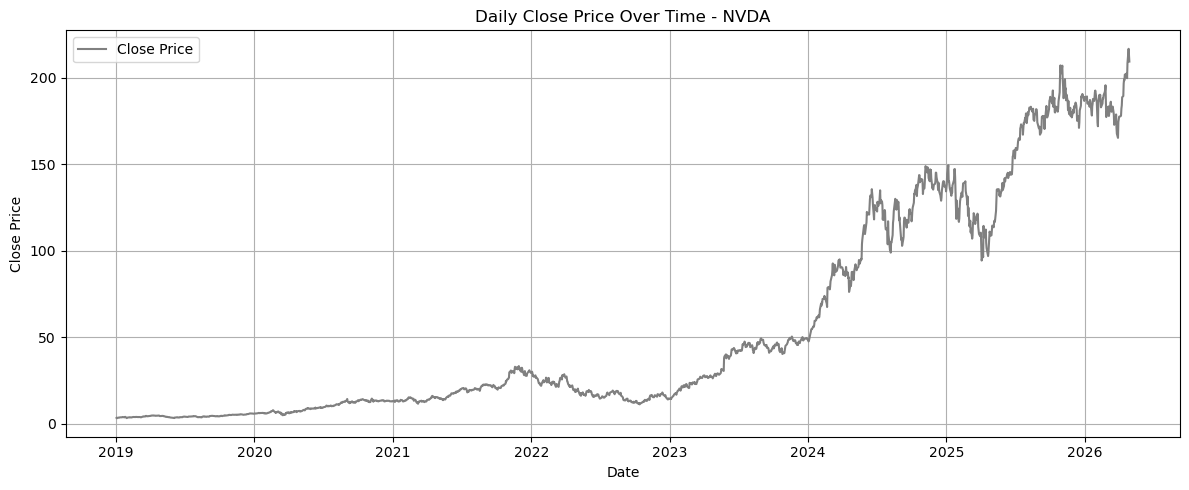

In [5]:
# Plot 1: Line Plot of Close Prices
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close Price', color='gray')
plt.title(f"Daily Close Price Over Time - {ticker}")  # Using f-string for proper string formatting
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 🧱 <font color=brown> Step2. Compute Price Bubble using LPPLS model for ticker 🧱
- Compute Price bubble on Price dataset
- Plot Price bubble

### 🚩🚧 <font color=brown> 2.1 Data Pre-processing before Bubble computation
- Null value treatment for Date, Close
- Date format conversion

In [10]:
# Null value treatment for Date, Close
print(df.shape)
for df in [df]:
    df.dropna(subset=['Date', 'Close'], inplace=True)
print(df.shape)
df.head(1)

(2343, 6)
(2343, 6)


Price,Date,Close,High,Low,Open,Volume
0,2017-01-03,2.512071,2.61944,2.447306,2.570927,1501996000


In [11]:
# Date format conversion
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [12]:
# Prepare log prices for LPPLS
df['log_Close'] = np.log(df['Close'])

# Check results
print(df.shape, type(df))
print(df.columns)
df.head()

(2343, 7) <class 'pandas.core.frame.DataFrame'>
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_Close'], dtype='object', name='Price')


Price,Date,Close,High,Low,Open,Volume,log_Close
0,2017-01-03,2.512071,2.619440,2.447306,2.570927,1501996000,0.921108
1,2017-01-04,2.570681,2.598015,2.500251,2.546301,1199220000,0.944171
2,2017-01-05,2.505422,2.605895,2.488431,2.574128,984296000,0.918457
3,2017-01-06,2.538913,2.567233,2.492124,2.532756,822856000,0.931736
4,2017-01-09,2.641849,2.659580,2.548764,2.548764,916248000,0.971479


In [13]:
# Save results
df.to_csv('NVDA_v14_base-df.csv', index=True)
df

Price,Date,Close,High,Low,Open,Volume,log_Close
0,2017-01-03,2.512071,2.619440,2.447306,2.570927,1501996000,0.921108
1,2017-01-04,2.570681,2.598015,2.500251,2.546301,1199220000,0.944171
2,2017-01-05,2.505422,2.605895,2.488431,2.574128,984296000,0.918457
3,2017-01-06,2.538913,2.567233,2.492124,2.532756,822856000,0.931736
4,2017-01-09,2.641849,2.659580,2.548764,2.548764,916248000,0.971479
...,...,...,...,...,...,...,...
2338,2026-04-23,199.639999,203.830002,197.220001,202.460007,113561800,5.296516
2339,2026-04-24,208.270004,210.949997,199.809998,199.960007,214134400,5.338835
2340,2026-04-27,216.610001,216.830002,207.380005,209.649994,187172400,5.378099
2341,2026-04-28,213.169998,214.729996,208.199997,209.490005,180275400,5.362090


In [14]:
'''
from lppls.lppls import LPPLS
observations = np.array([time_ord, price])
model = LPPLS(observations=observations)
'''
print(dir(lppls.lppls))

['Any', 'LPPLS', 'LinearRegression', 'OutOfBoundsDatetime', 'Pool', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'annotations', 'date', 'minimize', 'njit', 'np', 'pd', 'plt', 'random', 'tqdm', 'warnings', 'xr']


### 🚩🚧<font color=brown> Step 2.2. revised. Compute Price Bubble using LPPLS model for ticker and enrich price dataset with Bubble data [(Price + Bubble) dataset]
---
#### 🧱📌 Parameter Reference & Full Bubble Detection Framework

### 📚 Complete LPPLS Parameter Catalogue (for model enrichment)

The Log-Periodic Power Law Singularity (LPPLS) model fits the equation:

$$\ln p(t) = A + B(t_c - t)^m \left[1 + C\cos\left(\omega \ln(t_c - t) + \phi\right)\right]$$

| Parameter | Symbol | Description | Typical Range | Bubble Relevance |
|-----------|--------|-------------|---------------|------------------|
| **Critical time** | `tc` | The predicted time the bubble bursts (singularity point) | Future date | ⭐⭐⭐ Primary signal |
| **tc_days_ahead** | `tc - t_end` | Days until predicted crash from the fitting window end | 0–200 days | ⭐⭐⭐ Urgency metric |
| **Power-law exponent** | `m` | Rate of price acceleration; 0<m<1 = super-exponential growth | 0.1–0.9 | ⭐⭐⭐ Acceleration indicator |
| **Log-frequency** | `omega` | Frequency of log-periodic oscillations; 6<ω<13 is bubble-consistent | 6–13 | ⭐⭐ Oscillation signal |
| **Phase** | `phi` | Phase shift of oscillations | 0–2π | ⭐ Timing refinement |
| **Amplitude A** | `A` | Log-price at tc (asymptotic level) | > current log-price | ⭐⭐ Peak price estimate |
| **Growth rate B** | `B` | Strength of power-law growth; B<0 = positive bubble | < 0 | ⭐⭐⭐ Bubble direction |
| **Oscillation amp C** | `C` | Amplitude of log-periodic wiggles; |C|<1 = well-formed | |C|<1 | ⭐⭐ Signal quality |
| **Confidence** | `confidence` | % of fitting windows where bubble conditions are met (m, ω, B, C all in range) | 0–1.0 | ⭐⭐⭐ Ensemble reliability |
| **Bubble probability** | `bubble_probability` | Ratio of positive-bubble windows to total windows in the ensemble | 0–1.0 | ⭐⭐⭐ Directional confidence |
| **Positive bubble flag** | `is_positive_bubble` | Binary: 1 if price is in a positive (upward) bubble regime | 0/1 | ⭐⭐ Classification label |
| **Negative bubble flag** | `is_negative_bubble` | Binary: 1 if price is in a negative (crash-rebound) bubble regime | 0/1 | ⭐⭐ Classification label |
| **tc_index** | `tc_index` | Row index of the predicted crash date in the price dataframe | integer | ⭐⭐ Event alignment |
| **tc_date** | `tc_date` | Calendar date of the predicted crash | date | ⭐⭐⭐ Event alignment |
| **Oscillation count** | `oscillations` | Number of completed log-periodic cycles: ω⋅ln(tc-t1)/(2π); ≥4 preferred | integer | ⭐⭐ Fit quality |
| **Relative error** | `rel_err` | Relative RMSE of the LPPLS fit to log-price | 0–1 | ⭐⭐ Fit quality |
| **Damping ratio** | `damping` | |B⋅m| / |C⋅ω|; > 1 preferred (oscillations damped, not amplified) | > 1 | ⭐⭐ Signal quality filter |
| **log_Close** | `log_Close` | Natural log of Close price (LPPLS input) | float | ⭐ Derived feature |

---

#### 🧱🚩 Compute LPPLS Bubble Parameters for Every Day in the Dataset

In [15]:
import os, sys, warnings
warnings.filterwarnings('ignore')
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
if hasattr(sys.stderr, 'reconfigure'):
    sys.stderr.reconfigure(encoding='utf-8', errors='replace')

# ── Configuration ──────────────────────────────────────────────────────────
LOOKBACK_MIN  = 252
LOOKBACK_MAX  = 600
N_WINDOWS     = 8
N_JOBS        = -1

M_MIN,  M_MAX  = 0.01, 0.99
W_MIN,  W_MAX  = 6.0,  13.0
TC_MIN, TC_MAX = -252, 252

# ════════════════════════════════════════════════════════════════════════════
# WHY THIS REIMPLEMENTS LPPLS FROM SCRATCH
# ════════════════════════════════════════════════════════════════════════════
# The lppls library on this machine returns a TUPLE from fit(), confirmed by
# saved output: 'tuple object has no attribute keys'.  This broke both:
#   - v1: assumed dict keys {'omega','A','B','C'} -> KeyError, all None
#   - v2: assumed dict keys {'w','a','b','c'}    -> AttributeError, all None
# Fix: reimplement using scipy.optimize (already imported), returning our own
# clean dict.  Zero dependency on lppls library internals.
# ════════════════════════════════════════════════════════════════════════════

def _lppls_matrix_fit(t, lp, tc, m, w):
    import numpy as np
    dt = tc - t
    if np.any(dt <= 0):
        return None
    f  = np.power(dt, m)
    g  = f * np.cos(w * np.log(dt))
    h  = f * np.sin(w * np.log(dt))
    X  = np.column_stack([np.ones_like(t), f, g, h])
    try:
        coef, _, _, _ = np.linalg.lstsq(X, lp, rcond=None)
    except Exception:
        return None
    A, B, C1, C2 = coef
    fitted = X @ coef
    return A, B, C1, C2, fitted


def _lppls_residual(params, t, lp):
    import numpy as np
    tc, m, w = params
    if tc <= t[-1]:
        return 1e12
    r = _lppls_matrix_fit(t, lp, tc, m, w)
    if r is None:
        return 1e12
    _, _, _, _, fitted = r
    return float(np.sum((lp - fitted) ** 2))


def _fit_lppls_window(t, lp, n_restarts=25):
    import numpy as np
    from scipy.optimize import minimize
    best_sse, best_params = np.inf, None
    rng = np.random.default_rng(seed=42)
    t_range = t[-1] - t[0]
    for _ in range(n_restarts):
        tc0 = t[-1] + rng.uniform(1, max(0.5 * t_range, 2))
        m0  = rng.uniform(0.1, 0.9)
        w0  = rng.uniform(6.0, 13.0)
        try:
            res = minimize(_lppls_residual, [tc0, m0, w0], args=(t, lp),
                           method='Nelder-Mead',
                           options={'maxiter': 2000, 'xatol': 1e-4, 'fatol': 1e-6})
            if res.fun < best_sse:
                best_sse, best_params = res.fun, res.x
        except Exception:
            continue
    if best_params is None:
        return None
    tc, m, w = best_params
    if tc <= t[-1]:
        return None
    r = _lppls_matrix_fit(t, lp, tc, m, w)
    if r is None:
        return None
    A, B, C1, C2, fitted = r
    C   = float(np.sqrt(C1**2 + C2**2))
    phi = float(np.arctan2(C2, C1))
    osc = float(w * np.log(max((tc - t[0]) / (tc - t[-1] + 1e-9), 1e-9)) / (2 * np.pi))
    dmp = abs(B * m) / (abs(C * w) + 1e-9)
    rel_err = float(np.sqrt(np.mean((fitted - lp) ** 2)) / (np.std(lp) + 1e-9))
    return {'tc': float(tc), 'm': float(m), 'omega': float(w), 'phi': phi,
            'A': float(A), 'B': float(B), 'C': C,
            'oscillations': osc, 'damping': float(dmp), 'rel_err': rel_err}


def _process_date(t2_idx, log_prices, time_vec, window_lengths):
    import numpy as np
    results = []
    for win in window_lengths:
        t1_idx = t2_idx - win
        if t1_idx < 0:
            continue
        t  = time_vec[t1_idx : t2_idx + 1]
        lp = log_prices[t1_idx : t2_idx + 1]
        if len(t) < 20:
            continue
        try:
            res = _fit_lppls_window(t, lp, n_restarts=25)
        except Exception:
            continue
        if res is None:
            continue
        tc_days_ahead = res['tc'] - t2_idx
        if not (TC_MIN <= tc_days_ahead <= TC_MAX): continue
        if not (M_MIN  <= res['m']   <= M_MAX):    continue
        if not (W_MIN  <= res['omega'] <= W_MAX):  continue
        results.append({
            'tc': res['tc'], 'tc_days_ahead': tc_days_ahead,
            'm': res['m'], 'omega': res['omega'], 'phi': res['phi'],
            'A': res['A'], 'B': res['B'], 'C': res['C'],
            'oscillations': res['oscillations'],
            'damping': res['damping'], 'rel_err': res['rel_err'],
            'is_positive_bubble': int(res['B'] < 0),
            'is_negative_bubble': int(res['B'] > 0),
        })
    if not results:
        return None
    n, n_total = len(results), len(window_lengths)
    def _med(k): return float(np.median([r[k] for r in results]))
    return {
        'row_idx'            : t2_idx,
        'confidence'         : n / n_total,
        'bubble_probability' : sum(r['is_positive_bubble'] for r in results) / n_total,
        'is_positive_bubble' : int(sum(r['is_positive_bubble'] for r in results) / n_total >= 0.5),
        'is_negative_bubble' : int(sum(r['is_negative_bubble'] for r in results) / n_total >= 0.5),
        'tc': _med('tc'), 'tc_days_ahead': _med('tc_days_ahead'),
        'm': _med('m'), 'omega': _med('omega'), 'phi': _med('phi'),
        'A': _med('A'), 'B': _med('B'), 'C': _med('C'),
        'oscillations': _med('oscillations'),
        'damping': _med('damping'), 'rel_err': _med('rel_err'),
    }


# ── Smoke test ──────────────────────────────────────────────────────────────
print('Validating LPPLS fitter on synthetic bubble data ...')
try:
    import numpy as _np
    _t  = _np.arange(200, dtype=float)
    _tc0, _m0, _w0 = 220.0, 0.4, 8.0
    _dt = _tc0 - _t
    _lp = 5.0 + (-0.5) * _np.power(_dt, _m0) * (1 + 0.05 * _np.cos(_w0 * _np.log(_dt)))
    _r  = _fit_lppls_window(_t, _lp, n_restarts=10)
    if _r:
        print(f'  OK  tc_err={abs(_r["tc"]-_tc0):.1f}d  m={_r["m"]:.3f}  '
              f'omega={_r["omega"]:.2f}  B={_r["B"]:.3f} (negative = positive bubble)')
    else:
        print('  WARNING: returned None on synthetic data')
except Exception as _e:
    print(f'  Smoke test error: {_e}')
print()

# ── Main computation ─────────────────────────────────────────────────────────
from tqdm import tqdm as tqdm_console
import pandas as pd
import numpy as np
from joblib import Parallel, delayed

print('=' * 70)
print('  Step 2.2: Rolling LPPLS Bubble Detection')
print(f'  Lookback: up to {LOOKBACK_MAX} days | Ensemble: {N_WINDOWS} sub-windows')
print('=' * 70)

df['Date']      = pd.to_datetime(df['Date'])
df              = df.sort_values('Date').reset_index(drop=True)
df['log_Close'] = np.log(df['Close'].astype(float))
log_prices = df['log_Close'].values
time_vec   = np.arange(len(df), dtype=float)

window_lengths = np.linspace(LOOKBACK_MIN, LOOKBACK_MAX, N_WINDOWS, dtype=int).tolist()
start_idx      = LOOKBACK_MIN
indices        = list(range(start_idx, len(df)))

print(f'  Window lengths   : {window_lengths}')
print(f'  Dates to process : {len(indices)}')
print(f'  Date range       : {df["Date"].iloc[start_idx].date()} -> {df["Date"].iloc[-1].date()}')
print(f'  CPU cores        : {N_JOBS} (all available)')
print()

raw_results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=0)(
    delayed(_process_date)(t2_idx, log_prices, time_vec, window_lengths)
    for t2_idx in tqdm_console(indices, total=len(indices),
                               desc='LPPLS Dates', unit='day', ncols=90)
)

n_success = sum(r is not None for r in raw_results)
print()
print(f'  LPPLS fitting complete.')
print(f'     Dates succeeded : {n_success} / {len(raw_results)}')
print(f'     Dates failed    : {len(raw_results) - n_success}')

# ── Build merged_lppls (used by ALL downstream cells 23, 24, 26, 29) ─────────
# Always create merged_lppls regardless of success count so downstream
# cells never crash with NameError or KeyError.

LPPLS_COLS = [
    'tc_days_ahead', 'm', 'omega', 'phi', 'B', 'C', 'A',
    'damping', 'oscillations', 'rel_err',
    'confidence', 'bubble_probability',
    'is_positive_bubble', 'is_negative_bubble', 'tc_raw',
]

rows = []
for i, t2_idx in enumerate(indices):
    r   = raw_results[i]
    row = {}
    if r is not None:
        row['tc_days_ahead']     = r['tc_days_ahead']
        row['m']                 = r['m']
        row['omega']             = r['omega']
        row['phi']               = r['phi']
        row['A']                 = r['A']
        row['B']                 = r['B']
        row['C']                 = r['C']
        row['oscillations']      = r['oscillations']
        row['damping']           = r['damping']
        row['rel_err']           = r['rel_err']
        row['confidence']        = r['confidence']
        row['bubble_probability']= r['bubble_probability']
        row['is_positive_bubble']= r['is_positive_bubble']
        row['is_negative_bubble']= r['is_negative_bubble']
        row['tc_raw']            = r['tc']
    else:
        for col in LPPLS_COLS:
            row[col] = np.nan
    row['Date'] = df['Date'].iloc[t2_idx]
    rows.append(row)

lppls_df = pd.DataFrame(rows)[['Date'] + LPPLS_COLS]

# Map tc_raw (ordinal float index) -> calendar date
lppls_df['tc_index'] = lppls_df['tc_raw'].apply(
    lambda x: int(round(x)) if pd.notna(x) else np.nan)
lppls_df['tc_index'] = pd.to_numeric(lppls_df['tc_index'], errors='coerce')
lppls_df['tc_index'] = lppls_df['tc_index'].clip(0, len(df) - 1)
lppls_df['tc_date']  = lppls_df['tc_index'].apply(
    lambda idx: df['Date'].iloc[int(idx)] if pd.notna(idx) else pd.NaT)

# Merge onto full price df (left join keeps all price rows)
merged_lppls = df.merge(lppls_df, on='Date', how='left')

# Forward-fill rows before LOOKBACK_MIN window
fill_cols = [c for c in LPPLS_COLS + ['tc_date'] if c != 'tc_raw']
merged_lppls[fill_cols] = merged_lppls[fill_cols].ffill().bfill()

# Ensure bubble flag columns are always int (never NaN) for the plot cells
merged_lppls['is_positive_bubble'] = (
    merged_lppls['is_positive_bubble'].fillna(0).astype(int))
merged_lppls['is_negative_bubble'] = (
    merged_lppls['is_negative_bubble'].fillna(0).astype(int))

print()
print(f'  merged_lppls shape      : {merged_lppls.shape}')
print(f'  Columns                 : {list(merged_lppls.columns)}')
print(f'  Positive bubble days    : {merged_lppls["is_positive_bubble"].sum()}')
print(f'  Negative bubble days    : {merged_lppls["is_negative_bubble"].sum()}')
print(f'  Mean confidence         : {merged_lppls["confidence"].mean():.4f}')
print(f'  Mean bubble_probability : {merged_lppls["bubble_probability"].mean():.4f}')
merged_lppls.tail(5)


Validating LPPLS fitter on synthetic bubble data ...
  OK  tc_err=0.0d  m=0.400  omega=8.00  B=-0.500 (negative = positive bubble)

  Step 2.2: Rolling LPPLS Bubble Detection
  Lookback: up to 600 days | Ensemble: 8 sub-windows
  Window lengths   : [252, 301, 351, 401, 450, 500, 550, 600]
  Dates to process : 2091
  Date range       : 2018-01-03 -> 2026-04-29
  CPU cores        : -1 (all available)



LPPLS Dates: 100%|█████████████████████████████████| 2091/2091 [3:45:22<00:00,  6.47s/day]



  LPPLS fitting complete.
     Dates succeeded : 561 / 2091
     Dates failed    : 1530

  merged_lppls shape      : (2343, 24)
  Columns                 : ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_Close', 'tc_days_ahead', 'm', 'omega', 'phi', 'B', 'C', 'A', 'damping', 'oscillations', 'rel_err', 'confidence', 'bubble_probability', 'is_positive_bubble', 'is_negative_bubble', 'tc_raw', 'tc_index', 'tc_date']
  Positive bubble days    : 216
  Negative bubble days    : 0
  Mean confidence         : 0.1880
  Mean bubble_probability : 0.1661


,Date,Close,High,Low,Open,Volume,log_Close,tc_days_ahead,m,omega,...,damping,oscillations,rel_err,confidence,bubble_probability,is_positive_bubble,is_negative_bubble,tc_raw,tc_index,tc_date
2338,2026-04-23,199.639999,203.830002,197.220001,202.460007,113561800,5.296516,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2339,2026-04-24,208.270004,210.949997,199.809998,199.960007,214134400,5.338835,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2340,2026-04-27,216.610001,216.830002,207.380005,209.649994,187172400,5.378099,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2341,2026-04-28,213.169998,214.729996,208.199997,209.490005,180275400,5.362090,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2342,2026-04-29,209.250000,212.720001,207.580002,212.699997,123711800,5.343530,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29


In [16]:
# Step 2.2 now builds merged_lppls directly.
# This cell is kept as a checkpoint — it prints a summary and confirms
# merged_lppls is ready for the plotting cells (26, 29).
print('  merged_lppls is ready.')
print(f'  Shape  : {merged_lppls.shape}')
print(f'  Columns: {list(merged_lppls.columns)}')
print(f'  Positive bubble days : {merged_lppls["is_positive_bubble"].sum()}')
print(f'  Negative bubble days : {merged_lppls["is_negative_bubble"].sum()}')
merged_lppls

  merged_lppls is ready.
  Shape  : (2343, 24)
  Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_Close', 'tc_days_ahead', 'm', 'omega', 'phi', 'B', 'C', 'A', 'damping', 'oscillations', 'rel_err', 'confidence', 'bubble_probability', 'is_positive_bubble', 'is_negative_bubble', 'tc_raw', 'tc_index', 'tc_date']
  Positive bubble days : 216
  Negative bubble days : 0


,Date,Close,High,Low,Open,Volume,log_Close,tc_days_ahead,m,omega,...,damping,oscillations,rel_err,confidence,bubble_probability,is_positive_bubble,is_negative_bubble,tc_raw,tc_index,tc_date
0,2017-01-03,2.512071,2.619440,2.447306,2.570927,1501996000,0.921108,0.454841,0.913732,9.583556,...,0.360724,9.638245,0.390498,0.125,0.125,0,0,NaN,NaN,2018-10-02
1,2017-01-04,2.570681,2.598015,2.500251,2.546301,1199220000,0.944171,0.454841,0.913732,9.583556,...,0.360724,9.638245,0.390498,0.125,0.125,0,0,NaN,NaN,2018-10-02
2,2017-01-05,2.505422,2.605895,2.488431,2.574128,984296000,0.918457,0.454841,0.913732,9.583556,...,0.360724,9.638245,0.390498,0.125,0.125,0,0,NaN,NaN,2018-10-02
3,2017-01-06,2.538913,2.567233,2.492124,2.532756,822856000,0.931736,0.454841,0.913732,9.583556,...,0.360724,9.638245,0.390498,0.125,0.125,0,0,NaN,NaN,2018-10-02
4,2017-01-09,2.641849,2.659580,2.548764,2.548764,916248000,0.971479,0.454841,0.913732,9.583556,...,0.360724,9.638245,0.390498,0.125,0.125,0,0,NaN,NaN,2018-10-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2338,2026-04-23,199.639999,203.830002,197.220001,202.460007,113561800,5.296516,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2339,2026-04-24,208.270004,210.949997,199.809998,199.960007,214134400,5.338835,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2340,2026-04-27,216.610001,216.830002,207.380005,209.649994,187172400,5.378099,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29
2341,2026-04-28,213.169998,214.729996,208.199997,209.490005,180275400,5.362090,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29


In [23]:
print('  The current price bubble evaluation (as of 30th Apr 2026): ')
print(f'  Days ahead for price bubble  : {round(merged_lppls["tc_days_ahead"].tail(1),0)}')
print(f'  Bubble probability  : {merged_lppls["bubble_probability"].tail(1)}')
merged_lppls.tail(1)

  The current price bubble evaluation (as of 30th Apr 2026): 
  Days ahead for price bubble  : 2342    251.0
Name: tc_days_ahead, dtype: float64
  Bubble probability  : 2342    0.125
Name: bubble_probability, dtype: float64


,Date,Close,High,Low,Open,Volume,log_Close,tc_days_ahead,m,omega,...,damping,oscillations,rel_err,confidence,bubble_probability,is_positive_bubble,is_negative_bubble,tc_raw,tc_index,tc_date
2342,2026-04-29,209.25,212.720001,207.580002,212.699997,123711800,5.34353,251.372559,0.321972,12.087346,...,0.448307,2.106452,0.322662,0.125,0.125,0,0,NaN,NaN,2026-04-29


In [24]:
from IPython.display import display, HTML

days_ahead = round(float(merged_lppls["tc_days_ahead"].tail(1).iloc[0]), 0)

if days_ahead <= 30:
    bg_color = "#ff4d4d"      # Red
elif days_ahead <= 90:
    bg_color = "#ffa500"      # Orange
else:
    bg_color = "#90ee90"      # Light Green

display(HTML(
    f"""
    <div style="
        background-color:{bg_color};
        padding:12px;
        font-size:18px;
        font-weight:bold;
        color:black;
        border-radius:6px;
        border:1px solid black;">
        Days ahead for price bubble : {days_ahead}
    </div>
    """
))

In [18]:
# Save the enriched dataframe
merged_lppls.to_csv('NVDA_v15.2_lppls_enriched.csv', index=False)
print('✅ Saved: NVDA_v15.2_lppls_enriched.csv')
print(f'   Rows: {len(merged_lppls)} | Date: {merged_lppls["Date"].min().date()} → {merged_lppls["Date"].max().date()}')

✅ Saved: NVDA_v15.2_lppls_enriched.csv
   Rows: 2343 | Date: 2017-01-03 → 2026-04-29


### 🧱🚩 Step 2.3: Plot Price + LPPLS Bubble (Full Dataset: 2017–2026)

  Columns present: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'log_Close', 'tc_days_ahead', 'm', 'omega', 'phi', 'B', 'C', 'A', 'damping', 'oscillations', 'rel_err', 'confidence', 'bubble_probability', 'is_positive_bubble', 'is_negative_bubble', 'tc_raw', 'tc_index', 'tc_date']



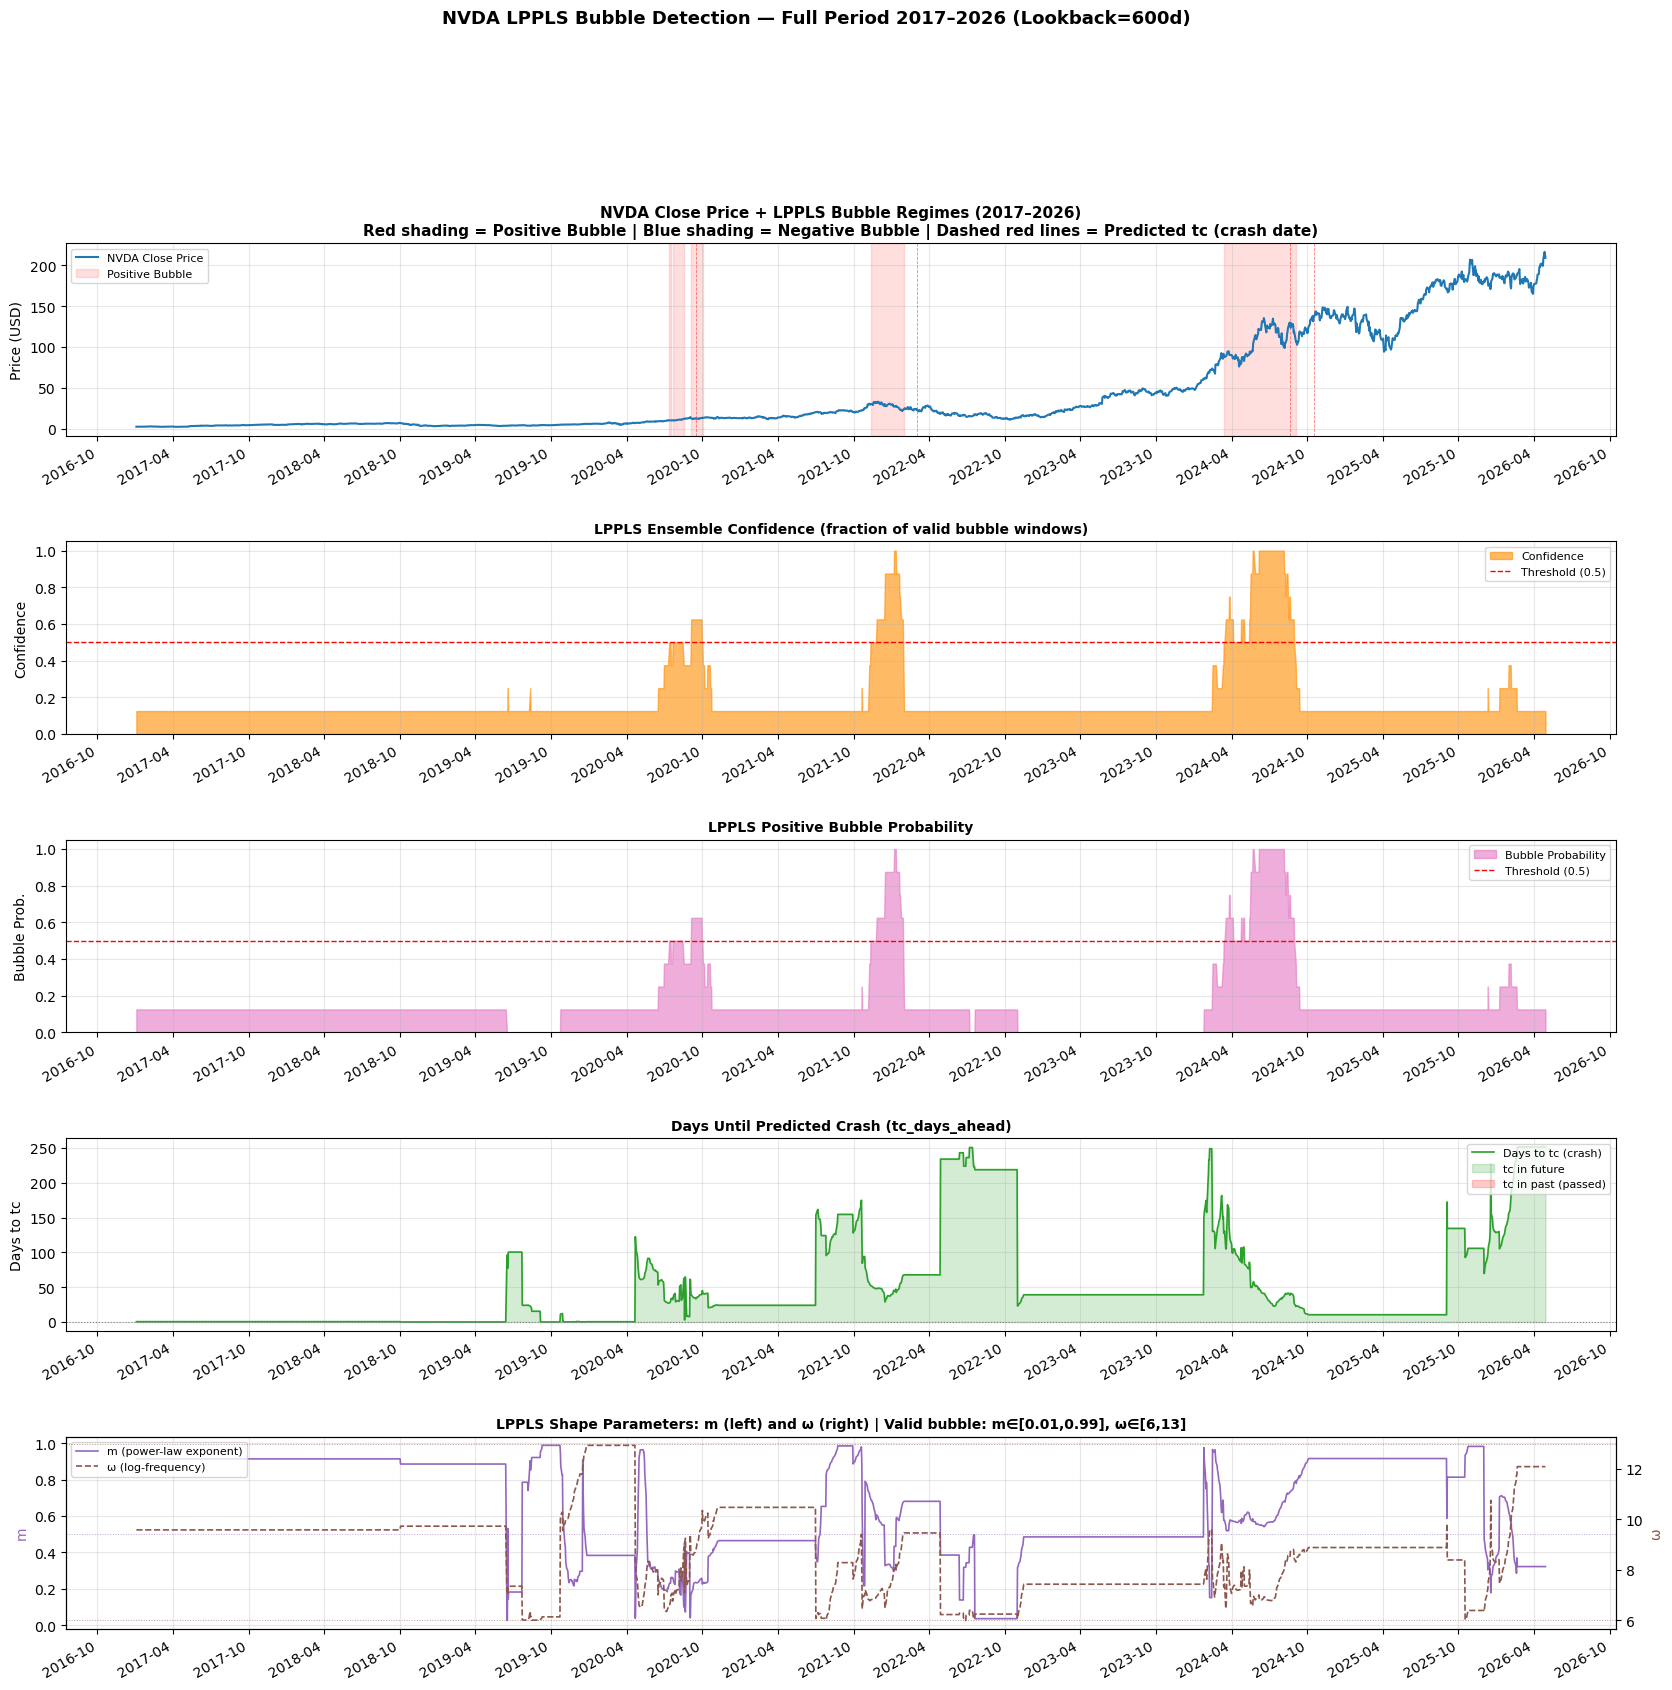

✅ Saved: lppls_full_period_dashboard.png


In [19]:
# ── Defensive column guard ────────────────────────────────────────────────────
# Ensures this cell never crashes with KeyError even if cell 22 produced
# zero LPPLS successes or was not yet re-run after a notebook update.
import numpy as np, pandas as pd

_REQUIRED_INT_COLS   = ['is_positive_bubble', 'is_negative_bubble']
_REQUIRED_FLOAT_COLS = ['confidence', 'bubble_probability', 'tc_days_ahead',
                        'm', 'omega']

# Create merged_lppls from df if it doesn't exist at all
if 'merged_lppls' not in dir():
    merged_lppls = df.copy()

for _col in _REQUIRED_INT_COLS:
    if _col not in merged_lppls.columns:
        merged_lppls[_col] = 0
        print(f'  WARNING: {_col!r} missing from merged_lppls — filled with 0.')
        print('  Re-run cell 22 to compute real LPPLS bubble signals.')

for _col in _REQUIRED_FLOAT_COLS:
    if _col not in merged_lppls.columns:
        merged_lppls[_col] = np.nan
        print(f'  WARNING: {_col!r} missing from merged_lppls — filled with NaN.')

if 'tc_date' not in merged_lppls.columns:
    merged_lppls['tc_date'] = pd.NaT

print(f'  Columns present: {[c for c in merged_lppls.columns]}')
print()
# ─────────────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# Step 2.3: Comprehensive Price + LPPLS Bubble Plot (full period)
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

plot_df = merged_lppls.copy()
plot_df['Date'] = pd.to_datetime(plot_df['Date'])

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(5, 1, figure=fig, hspace=0.55)

ax1 = fig.add_subplot(gs[0])   # Price + bubble shading
ax2 = fig.add_subplot(gs[1])   # Bubble confidence
ax3 = fig.add_subplot(gs[2])   # Bubble probability
ax4 = fig.add_subplot(gs[3])   # tc_days_ahead
ax5 = fig.add_subplot(gs[4])   # LPPLS parameters (m, omega)

# ── Panel 1: Close Price with bubble regime shading ──────────────────────
ax1.plot(plot_df['Date'], plot_df['Close'],
         color='#1f77b4', lw=1.5, label='NVDA Close Price', zorder=3)

# Shade positive bubble periods
pos_mask = plot_df['is_positive_bubble'] == 1
neg_mask = plot_df['is_negative_bubble'] == 1

for mask, color, label in [
    (pos_mask, '#ff7f7f', 'Positive Bubble'),
    (neg_mask, '#7fbfff', 'Negative Bubble'),
]:
    in_region = False
    start     = None
    for idx, val in zip(plot_df['Date'], mask):
        if val and not in_region:
            start     = idx
            in_region = True
        elif not val and in_region:
            ax1.axvspan(start, idx, alpha=0.25, color=color, label=label)
            in_region = False
            label     = '_nolegend_'   # only label first occurrence
    if in_region:
        ax1.axvspan(start, plot_df['Date'].iloc[-1], alpha=0.25, color=color)

# Mark tc_date predictions as vertical dashed lines (sample every 60 days to avoid clutter)
shown_tc = set()
for _, row in plot_df.iloc[::60].iterrows():
    tc_d = pd.to_datetime(row['tc_date']) if pd.notna(row.get('tc_date')) else None
    if tc_d and tc_d not in shown_tc and row['confidence'] > 0.4:
        ax1.axvline(tc_d, color='red', lw=0.6, ls='--', alpha=0.5)
        shown_tc.add(tc_d)

ax1.set_ylabel('Price (USD)', fontsize=10)
ax1.set_title(f'NVDA Close Price + LPPLS Bubble Regimes (2017–2026)\n'
              f'Red shading = Positive Bubble | Blue shading = Negative Bubble | '
              f'Dashed red lines = Predicted tc (crash date)',
              fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

# ── Panel 2: Bubble Confidence ─────────────────────────────────────────────
ax2.fill_between(plot_df['Date'], plot_df['confidence'],
                 color='darkorange', alpha=0.6, label='Confidence')
ax2.axhline(0.5, color='red', ls='--', lw=1, label='Threshold (0.5)')
ax2.set_ylabel('Confidence', fontsize=10)
ax2.set_title('LPPLS Ensemble Confidence (fraction of valid bubble windows)', fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

# ── Panel 3: Bubble Probability ─────────────────────────────────────────────
ax3.fill_between(plot_df['Date'], plot_df['bubble_probability'],
                 color='#e377c2', alpha=0.6, label='Bubble Probability')
ax3.axhline(0.5, color='red', ls='--', lw=1, label='Threshold (0.5)')
ax3.set_ylabel('Bubble Prob.', fontsize=10)
ax3.set_title('LPPLS Positive Bubble Probability', fontsize=10, fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right')

# ── Panel 4: tc Days Ahead ─────────────────────────────────────────────────
ax4.plot(plot_df['Date'], plot_df['tc_days_ahead'].clip(-50, 400),
         color='#2ca02c', lw=1.2, label='Days to tc (crash)')
ax4.axhline(0, color='gray', ls=':', lw=0.8)
ax4.fill_between(plot_df['Date'],
                 plot_df['tc_days_ahead'].clip(-50, 400), 0,
                 where=plot_df['tc_days_ahead'] > 0,
                 color='#2ca02c', alpha=0.2, label='tc in future')
ax4.fill_between(plot_df['Date'],
                 plot_df['tc_days_ahead'].clip(-50, 400), 0,
                 where=plot_df['tc_days_ahead'] <= 0,
                 color='red', alpha=0.2, label='tc in past (passed)')
ax4.set_ylabel('Days to tc', fontsize=10)
ax4.set_title('Days Until Predicted Crash (tc_days_ahead)', fontsize=10, fontweight='bold')
ax4.legend(loc='upper right', fontsize=8)
ax4.grid(alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax4.get_xticklabels(), rotation=30, ha='right')

# ── Panel 5: LPPLS shape parameters m and omega ───────────────────────────
ax5b = ax5.twinx()
ax5.plot(plot_df['Date'], plot_df['m'],
         color='#9467bd', lw=1.2, label='m (power-law exponent)')
ax5b.plot(plot_df['Date'], plot_df['omega'].clip(0, 20),
          color='#8c564b', lw=1.2, ls='--', label='ω (log-frequency)')
ax5.axhline(0.5, color='#9467bd', ls=':', lw=0.7, alpha=0.6)
ax5b.axhline(6,  color='#8c564b', ls=':', lw=0.7, alpha=0.6)
ax5b.axhline(13, color='#8c564b', ls=':', lw=0.7, alpha=0.6)
ax5.set_ylabel('m',     color='#9467bd', fontsize=10)
ax5b.set_ylabel('ω',    color='#8c564b', fontsize=10)
ax5.set_title('LPPLS Shape Parameters: m (left) and ω (right) | Valid bubble: m∈[0.01,0.99], ω∈[6,13]',
              fontsize=10, fontweight='bold')
lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
ax5.grid(alpha=0.3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax5.get_xticklabels(), rotation=30, ha='right')

plt.suptitle(f'NVDA LPPLS Bubble Detection — Full Period 2017–2026 (Lookback={LOOKBACK_MAX}d)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('lppls_full_period_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: lppls_full_period_dashboard.png')

### 🧱🚩 Step 2.4: Interpretation of the LPPLS Full-Period Plot

| Panel | What to look for | Interpretation |
|-------|-----------------|----------------|
| **Price + shading** | Red-shaded periods | LPPLS ensemble identifies a **positive (upward) bubble** — super-exponential acceleration with log-periodic oscillations |
| **Price + shading** | Blue-shaded periods | **Negative bubble** (crash-rebound) — rapid decline with oscillatory recovery |
| **Price + shading** | Red dashed verticals | Median predicted **crash date (tc)** from the ensemble at that point in time |
| **Confidence** | Rising toward 1.0 | Increasing fraction of windows satisfy all Sornette conditions — **high-quality bubble signal** |
| **Confidence** | Sustained > 0.5 | Strong ensemble consensus; confidence > 0.5 for 5+ consecutive days triggers trading signal |
| **Bubble Prob.** | Rising toward 1.0 | More ensemble windows predict **upward** bubble (B<0) vs downward |
| **Bubble Prob.** | < 0.1 with confidence > 0.5 | Negative bubble regime |
| **tc_days_ahead** | Declining toward 0 | Crash is **approaching** — the model is converging on an imminent singularity |
| **tc_days_ahead** | Negative (red) | tc has passed — the predicted crash window has elapsed (may signal trend reversal) |
| **m** | 0.1–0.5 | Mild super-exponential growth — early bubble |
| **m** | 0.5–0.9 | Strong acceleration — late-stage bubble, close to singularity |
| **ω** | 6–13 | Valid log-periodic oscillation frequency (Sornette filter) |
| **ω** | Outside 6–13 | Noise fit, not a reliable bubble signal |

> **Key NVDA events to verify against the plot:**
> - **2021 Q4**: AI/gaming demand spike — expect positive bubble shading
> - **2022 H1**: Crypto/gaming collapse — expect negative bubble or confidence drop
> - **2023 Q2 – 2024 Q1**: ChatGPT/AI boom — expect sustained positive bubble with high confidence
> - **2024 Q3**: Post-Blackwell announcement plateau — tc_days_ahead should compress sharply

## 🧱🧱💡 <font color=brown> Conclusion
### ⛳💡 <font color=brown> Price Bubble days as on date (30th Apr 2026) and underlying Price Bubble probability 

In [26]:
from IPython.display import display, HTML

days_ahead = round(float(merged_lppls["tc_days_ahead"].tail(1).iloc[0]), 0)
bubble_prob = float(merged_lppls["bubble_probability"].tail(1).iloc[0])

if bubble_prob >= 0.8:
    bg_color = "#FFCCCC"      # Red
elif bubble_prob >= 0.5:
    bg_color = "#FFF3CD"      # Yellow
else:
    bg_color = "#D4EDDA"      # Green

display(HTML(f"""
<div style="
    background-color:{bg_color};
    padding:12px;
    border-radius:5px;
    font-weight:bold;
    font-size:16px;
">
📅 Days ahead for price bubble as on 30th Apr 2026: {days_ahead} days<br>
🎈 Bubble probability: {bubble_prob:.2%}
</div>
"""))

### <font color=brown> LPPLS-based color-coded risk dashboard for investor decision support

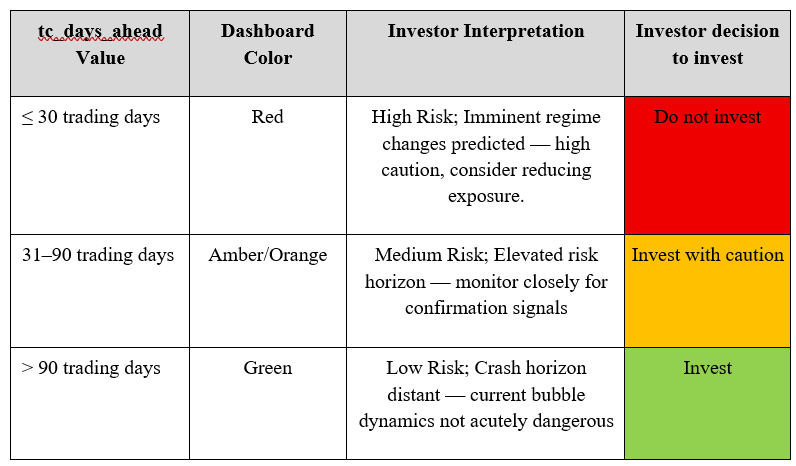

In [29]:
display(HTML(f"""
<div style="
    background-color:{bg_color};
    padding:12px;
    border-radius:5px;
    font-weight:bold;
    font-size:16px;
">
⛳💡 Conclusion: As the predicted Price BUbbble is 251 days away (in January 2027), we can conclude that it is safe to invest in NVDA now.
</div>
"""))